In [15]:
import os
import glob
import random
from pathlib import Path
import numpy as np
from scipy.stats import kruskal
from scipy.stats import ttest_1samp
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata

import sys
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')
from utils_pheno import * 

# sys.path.append('/scratch/users/k21066795/BreastAgeNet')
# from utils_vis import boxplot_with_pvalue
# from utils_model import parse_wsi_id
# from utils_features import Reinhard
# import stardist
# import staintools
# from stardist.models import StarDist2D
# from stardist.plot import render_label
# from csbdeep.utils import normalize

import warnings
warnings.filterwarnings("ignore")

In [5]:
basedir = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS'
save_prefix = f"{basedir}/NBTs_phenotypes03/nuclei_quantification"
os.listdir(save_prefix)

['leiden_0.5_nuclei_pairwise_adj_pvalues.csv',
 'leiden_0.5_nuclei_adjust_pvalue_boxplot.pdf',
 'leiden_0.5_startdist',
 'leiden_0.5_nuclei_morphology_patchAggregate.csv',
 'leiden_0.5_nuclei_morphology.csv',
 'leiden_0.5_nuclei_counts_4levels_boxplot.pdf',
 'leiden_0.5_patch_examples',
 'leiden_0.5_HE']

In [6]:
# get patches from each cluster (Leiden_0.5)
WSIs = '/scratch/prj/cb_normalbreast/prj_BreastAgeNet/WSIs'
groupby = 'leiden_0.5'
PATCH = f'{save_prefix}/{groupby}_HE'
# os.makedirs(PATCH)

In [7]:
# read leiden clustering adata results 
file_path = f'{basedir}/NBTs_phenotypes03/adata/adata_NBTs_4levels.h5ad'
adata_normal = sc.read_h5ad(file_path)
patient_ids = []
for i in list(adata_normal.obs["wsi_id"]):
    if "_FPE_" in i:
        patient_id = str(i.split("_FPE_")[0])
        patient_ids.append(patient_id)
    else:
        patient_id = str(i.split("_")[1])
        patient_ids.append(patient_id)
adata_normal.obs["patient_id"] = patient_ids
adata_normal.obs["patient_id"] = adata_normal.obs["patient_id"].astype(str)
adata_normal.obs

,patient_id,age,patch_id,cohort,wsi_id,source,leiden_0.5,umap1,umap2,leiden_0.5_top_samples,leiden_1.0,leiden_1.5,leiden_2.0,risk
0,1003675,NaN,BRACS_1003675_N_1_1792_768,BRCAS,BRACS_1003675_N_1,N,1,3.759436,8.816525,False,0,1,1,2
1,1003675,NaN,BRACS_1003675_N_1_256_1024,BRCAS,BRACS_1003675_N_1,N,5,0.320499,4.078640,False,11,21,31,2
2,1003675,NaN,BRACS_1003675_N_1_1280_768,BRCAS,BRACS_1003675_N_1,N,1,4.204348,8.063508,False,0,1,1,2
3,1003675,NaN,BRACS_1003675_N_1_768_1024,BRCAS,BRACS_1003675_N_1,N,4,0.990095,4.295871,False,11,17,25,2
4,1003675,NaN,BRACS_1003675_N_1_256_1280,BRCAS,BRACS_1003675_N_1,N,5,0.473569,4.100793,False,11,21,31,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97271,773,NaN,BRACS_773_N_33_768_0,BRCAS,BRACS_773_N_33,N,1,3.437264,9.901889,False,0,14,28,2
97272,773,NaN,BRACS_773_N_33_768_256,BRCAS,BRACS_773_N_33,N,3,5.882754,1.325934,False,2,5,18,2
97273,773,NaN,BRACS_773_N_33_1280_512,BRCAS,BRACS_773_N_33,N,5,2.701497,2.551752,False,4,4,24,2
97274,773,NaN,BRACS_773_N_33_2048_512,BRCAS,BRACS_773_N_33,N,1,3.388751,4.773305,False,1,4,24,2


In [13]:
# save .png files
# df = adata_normal.obs.copy()
# patch_num = 3000
# for cluster_id in range(6):
#     patch_ids = list(df.loc[df[groupby] == cluster_id, "patch_id"])
#     print(len(patch_ids))
#     random.shuffle(patch_ids)
    
#     for patch_id in patch_ids[:patch_num]:
#         save_pt = f"{PATCH}/{patch_id}.tif"
#         print(save_pt)

#         if "BRACS" not in patch_id:
#             wsi_id = parse_wsi_id(patch_id)
#             try:
#                 wsi_path = glob.glob(f"{WSIs}/*/{wsi_id}*.*")[0]
#                 wsi = openslide.OpenSlide(wsi_path)
#                 x, y, patch_size = get_xy(patch_id)
#                 im = wsi.read_region((x, y), 0, (patch_size, patch_size)).convert("RGB")
#             except Exception as e:
#                 print(f"Error processing WSI {wsi_id} for patch {patch_id}: {e}")
#                 continue  
#         else:
#             BRCAS = '/scratch_tmp/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI'
#             roi_id = "_".join(patch_id.split("_")[:-2])
#             image_path = glob.glob(f"{BRCAS}/*/*/{roi_id}.png")[0] 
#             image = Image.open(image_path)
#             coordinates = patch_id.split('_')[-2:]  # Get the last two parts: x and y coordinates
#             x, y = int(coordinates[0]), int(coordinates[1])
#             im = crop_patch(image, x, y)

#         # save the normalised patch
#         patch_im_norm = Reinhard(np.array(im))
#         patch_im_norm = Image.fromarray(patch_im_norm)
#         patch_im_norm.save(save_pt)

print(f"There are raw {len(os.listdir(PATCH))} patches extarcted!") 

There are raw 15733 patches extarcted!


In [17]:
# StarDist nuclei segmentation of the sampled patches
NUCLEI = f'{save_prefix}/{groupby}_startdist'
# os.makedirs(NUCLEI, exist_ok=True)
# nuclei_csv = f"{save_prefix}/{groupby}_nuclei_morphology.csv"   # the file to save nuclei morphology quantification results

# for patch_id in os.listdir(PATCH): 
#     tar_pt = f'{NUCLEI}/{patch_id.replace(".tif", "_nu.tif")}'
#     if not os.path.exists(tar_pt):
#         try:
#             print(tar_pt)
#             patch_norm = Image.open(f"{PATCH}/{patch_id}")
#             patch_im_norm = np.array(patch_norm)
            
#             # apply StarDist to detect nuclei and save the mask
#             model = StarDist2D.from_pretrained('2D_versatile_he')
#             labels, details = model.predict_instances(normalize(patch_im_norm))
#             seg_im = Image.fromarray(labels.astype(bool))
#             seg_im.save(tar_pt)
#             print(f"{tar_pt} saved!")
#             # plot_contours(patch_im, details["coord"])
            
#             # compute nuclei features
#             nuclei_props_list = ["label", "area", "bbox_area", "extent", "eccentricity", "perimeter", "major_axis_length", "minor_axis_length", "solidity"]
#             props = regionprops_table(labels, properties=nuclei_props_list)
#             props_df = pd.DataFrame.from_dict(props)
#             props_df["Circularity"] = (4*np.pi*props_df["area"]) / (props_df["major_axis_length"]**2)
#             props_df["Elongation"] = props_df["major_axis_length"] / props_df["minor_axis_length"]
#             props_df["patch_id"] = patch_id.split('.tif')[0]
#             props_df["coord_x"] = details["points"][:,0]
#             props_df["coord_y"] = details["points"][:,1]
            
#             if not os.path.exists(nuclei_csv):
#                 props_df.to_csv(nuclei_csv, index=False)
#             else:
#                 props_df.to_csv(nuclei_csv, mode="a", header=False, index=False)
#         except:
#             pass

print(f"Nuclei segmentation has performed for {len(os.listdir(NUCLEI))} patches!") 
nuclei_df = pd.read_csv(nuclei_csv)
print(f"There are {len(nuclei_df)} nuclei quantified!")
nuclei_df.head()

Nuclei segmentation has performed for 15733 patches!
There are 561409 nuclei quantified!


,label,area,bbox_area,extent,eccentricity,perimeter,major_axis_length,minor_axis_length,solidity,Circularity,Elongation,patch_id,coord_x,coord_y
0,1,285.0,380.0,0.750000,0.305139,61.112698,19.533918,18.602300,0.956376,9.385902,1.050081,18000286_FPE_4_29272_38183_12721_8823_71_73_555,242,454
1,2,814.0,1080.0,0.753704,0.563075,105.740115,35.422562,29.273422,0.971360,8.152191,1.210059,18000286_FPE_4_29272_38183_12721_8823_71_73_555,470,24
2,3,678.0,868.0,0.781106,0.469835,95.254834,31.303697,27.633464,0.971347,8.694574,1.132818,18000286_FPE_4_29272_38183_12721_8823_71_73_555,140,420
3,4,679.0,891.0,0.762065,0.547223,96.669048,32.232548,26.978216,0.967236,8.212783,1.194762,18000286_FPE_4_29272_38183_12721_8823_71_73_555,108,396
4,5,481.0,621.0,0.774557,0.557675,79.597980,27.194375,22.572939,0.975659,8.173287,1.204733,18000286_FPE_4_29272_38183_12721_8823_71_73_555,472,208


In [61]:
# Aggregate nuclei-level morphology into patch-level table
# nuclei_df = pd.read_csv(nuclei_csv)
# nuclei_df = pd.merge(nuclei_df, adata_normal.obs.loc[:, ['patch_id', 'cohort', 'wsi_id', 'source', 'leiden_0.5']], on = 'patch_id')

agg_pt = f"{save_prefix}/{groupby}_nuclei_morphology_patchAggregate.csv"
# agg_df = nuclei_df.groupby('patch_id').agg({
#     'area': 'mean',
#     'bbox_area': 'mean',
#     'extent': 'mean',
#     'eccentricity': 'mean',
#     'perimeter': 'mean',
#     'major_axis_length': 'mean',
#     'minor_axis_length': 'mean',
#     'solidity': 'mean',
#     'Circularity': 'mean',
#     'Elongation': 'mean',
#     'patch_id': 'size',
#     'cohort': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
#     'wsi_id': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
#     'source': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
#     'leiden_0.5': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
# }).rename(columns={
#     'area': 'area_mean',
#     'bbox_area': 'bbox_area_mean',
#     'extent': 'extent_mean',
#     'eccentricity': 'eccentricity_mean',
#     'perimeter': 'perimeter_mean',
#     'major_axis_length': 'major_axis_length_mean',
#     'minor_axis_length': 'minor_axis_length_mean',
#     'solidity': 'solidity_mean',
#     'Circularity': 'circularity_mean',
#     'Elongation': 'elongation_mean',
#     'patch_id': 'nuclei_count'
# }).reset_index()
# agg_df.to_csv(agg_pt, index=False)


agg_df = pd.read_csv(agg_pt)
print(f"Mean values of nuclei quantifications were computed for {len(agg_df)} patches!")
agg_df.head()

Mean values of nuclei quantifications were computed for 15395 patches!


,patch_id,area_mean,bbox_area_mean,extent_mean,eccentricity_mean,perimeter_mean,major_axis_length_mean,minor_axis_length_mean,solidity_mean,circularity_mean,elongation_mean,nuclei_count,cohort,wsi_id,source,leiden_0.5
0,17027148_FPE_1_33274_15932_8580_7424_58_36_578,435.666667,636.750000,0.682728,0.744726,79.756271,30.183980,18.317316,0.951935,5.980464,1.791736,12,KHP,17027148_FPE_1,N_RM,1
1,17027148_FPE_1_33274_15932_8580_7424_69_39_578,393.000000,565.666667,0.683787,0.809851,75.745863,28.951985,16.680905,0.948906,5.573351,1.727821,3,KHP,17027148_FPE_1,N_RM,2
2,17027148_FPE_2_12580_1986_92469_86893_100_80_555,795.000000,1050.000000,0.756404,0.859368,115.547727,45.988648,22.576476,0.946489,4.837108,2.096827,2,KHP,17027148_FPE_2,N_RM,2
3,17027148_FPE_2_12580_1986_92469_86893_105_90_555,515.000000,667.000000,0.772114,0.617495,83.012193,28.899565,22.731678,0.969868,7.748800,1.271334,1,KHP,17027148_FPE_2,N_RM,2
4,17027148_FPE_2_12580_1986_92469_86893_181_96_555,239.333333,398.666667,0.622276,0.916548,65.941125,28.244730,10.918448,0.940453,3.853194,2.598899,3,KHP,17027148_FPE_2,N_RM,2


In [9]:
# Pairwise comparison of nuclei morphology quantifications between phenotypes P0-P3 (Wilcoxon rank-sum test)
features = ['nuclei_count', 'area_mean', "perimeter_mean", "major_axis_length_mean", 
            "minor_axis_length_mean", "extent_mean", 'circularity_mean', 'elongation_mean', 
            "eccentricity_mean", "solidity_mean"]
save_pt = f"{save_prefix}/{groupby}_nuclei_pairwise_adj_pvalues.csv"
# pval_df = compute_adjusted_pvalues(df=agg_df, features=features, 
#                                    group_label="leiden_0.5", group_order = [0,1,2,3,4,5], save_pt=save_pt)

pval_df = pd.read_csv(save_pt)
pval_df

,Feature,Group 1,Group 2,Adjusted p-value,Significance
0,nuclei_count,0,1,0.000000e+00,***
1,nuclei_count,0,2,0.000000e+00,***
2,nuclei_count,0,3,0.000000e+00,***
3,nuclei_count,0,4,1.249053e-197,***
4,nuclei_count,0,5,7.962569e-06,***
...,...,...,...,...,...
145,solidity_mean,2,4,0.000000e+00,***
146,solidity_mean,2,5,2.325794e-163,***
147,solidity_mean,3,4,0.000000e+00,***
148,solidity_mean,3,5,4.434714e-185,***


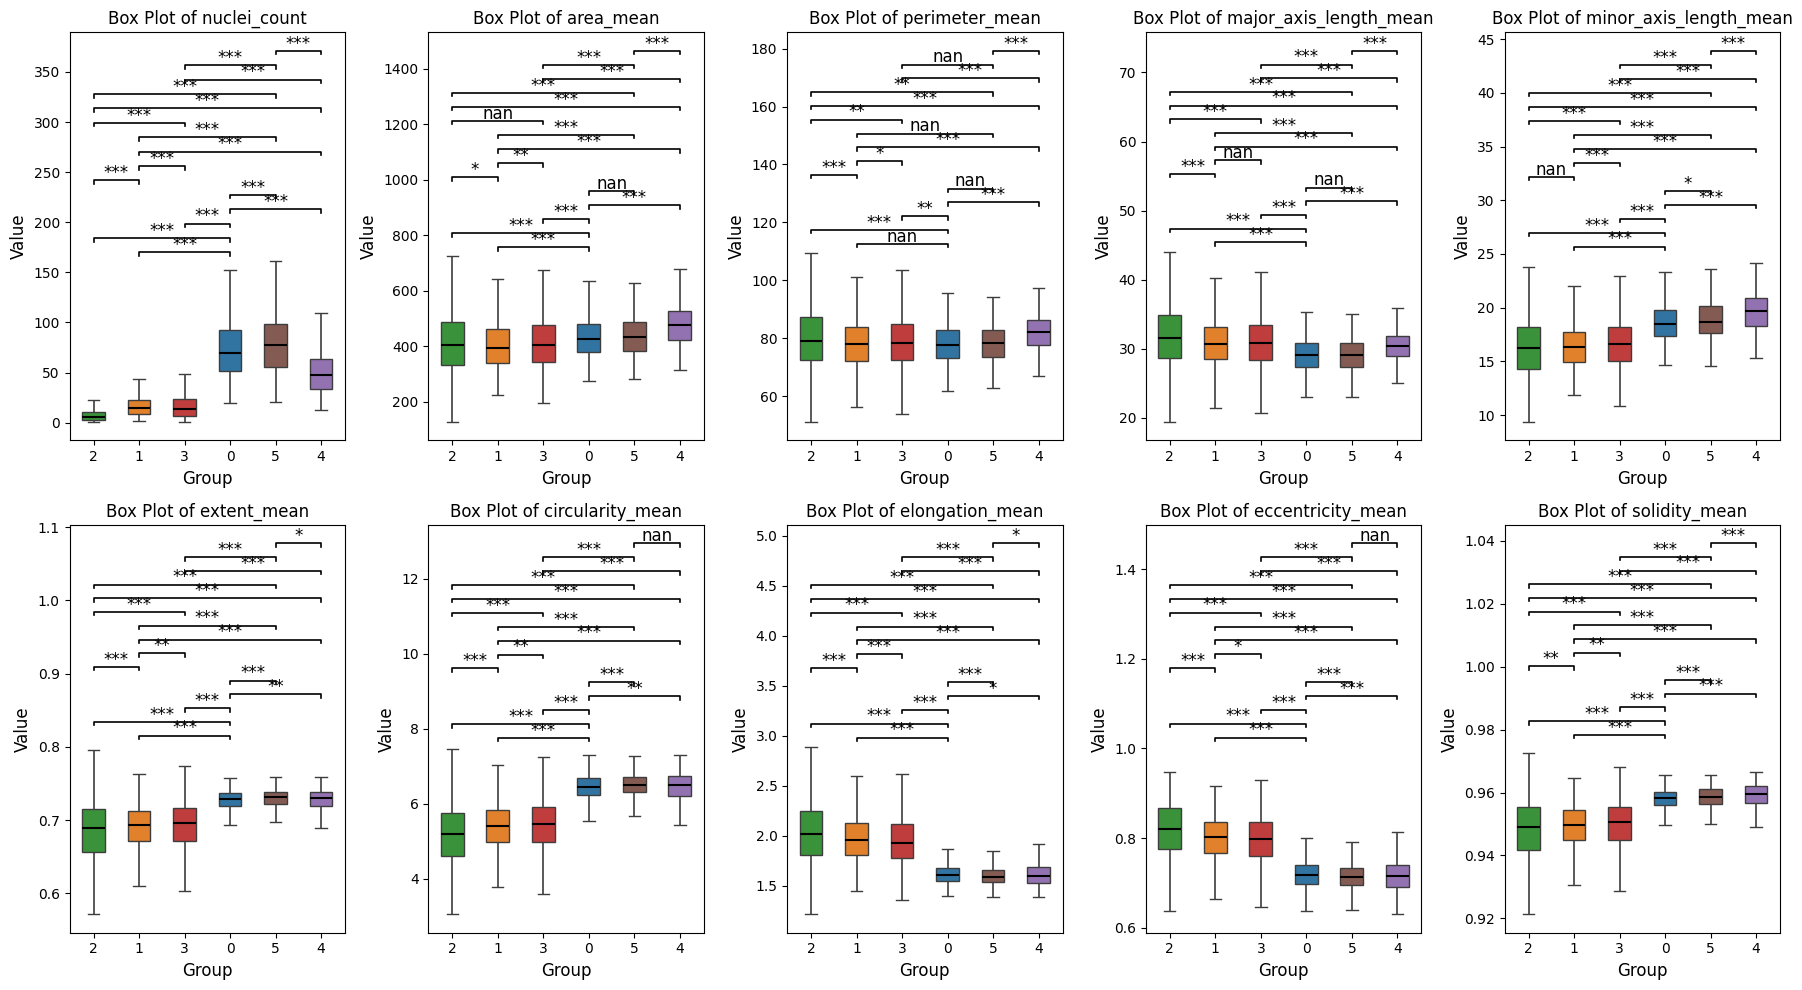

In [16]:
# Boxplot visualisation of pairwise comparison of nuclei morphology quantifications between Leiden0.5 clusters (Wilcoxon rank-sum test)
group_colors = {0: adata_normal.uns['leiden_0.5_colors'][0], 
          1: adata_normal.uns['leiden_0.5_colors'][1],
          2: adata_normal.uns['leiden_0.5_colors'][2],
          3: adata_normal.uns['leiden_0.5_colors'][3], 
          4: adata_normal.uns['leiden_0.5_colors'][4],
          5: adata_normal.uns['leiden_0.5_colors'][5]}


fig, axes = plt.subplots(2, 5, figsize=(18, 10))  
axes = axes.flatten()
for i, feature in enumerate(features):    
    boxplot_with_pvalue(agg_df, feature=feature, group_label="leiden_0.5", group_order=[2,1,3,0,5,4],
                        group_colors=group_colors, pval_df=pval_df, ax=axes[i], figsize=(12, 6), box_width=0.5)
plt.tight_layout()
# save_pt = f"{save_prefix}/{groupby}_nuclei_adjust_pvalue_boxplot.pdf"
# plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [82]:
# comapre nuclei features among epithelium/stroma clusters identified at resolutions: 0.5, 1.0, 1.5, 2.0
# cluster_order_0 = ['0', '1', '2', '3', '4', '5']
# cluster_order_1 = ['8', '0', '7', '12', '3', '10', '2', '9', '1', '4', '5', '6', '11']
# cluster_order_2 = ['12', '20', '1', '13', '14', '9', '18', '19', '8', '11', '15', '0', '6', '4', '7', '3', '16', '2', '5', '10', '17', '21']
# cluster_order_3 = ['10', '26', '1', '11', '29', '6', '28', '8', '23', '17', '14', '21', '9', '22', '27', '0', '13', '15', '30', '7', '20', '3', '2', '16', '4', '12', '5', '18', '24', '19', '25', '31']

# cluster_order_05_epi = ['0', '4', '5']
# cluster_order_05_str = ['1', '2', '3']
# cluster_order_10_epi = ['8', '1', '4', '5', '6', '11']
# cluster_order_10_str = ['0', '7', '3', '10', '2', '9', '12']
# cluster_order_15_epi = ['12', '20', '4', '7', '3', '16', '2', '5', '10', '17', '21']
# cluster_order_15_str = ['13', '14', '9', '18', '19', '8', '11', '15', '0', '6']

cluster_order_05_epi = ['0', '4', '5']
cluster_order_05_str = ['1', '2', '3']
cluster_order_10_epi = ['1', '4', '5', '6', '8', '11']
cluster_order_10_str = ['0', '2', '3', '7', '9', '10', '12']
cluster_order_15_epi = ['2', '3', '4', '5', '7', '10', '12', '16', '17', '20', '21']
cluster_order_15_str = ['0', '6', '8', '9', '11', '13', '14', '15', '18', '19']

# merge nuclei quantifications with leiden clusters identified at resolutions: 0.5, 1.0, 1.5, 2.0
agg_df_leiden = pd.merge(agg_df, adata_normal.obs.loc[:, ['patch_id', 'leiden_1.0','leiden_1.5']], how='left', on='patch_id')
agg_df_leiden['leiden_0.5'] = agg_df_leiden['leiden_0.5'].astype(str)
agg_df_leiden

,patch_id,area_mean,bbox_area_mean,extent_mean,eccentricity_mean,perimeter_mean,major_axis_length_mean,minor_axis_length_mean,solidity_mean,circularity_mean,elongation_mean,nuclei_count,cohort,wsi_id,source,leiden_0.5,leiden_1.0,leiden_1.5
0,17027148_FPE_1_33274_15932_8580_7424_58_36_578,435.666667,636.750000,0.682728,0.744726,79.756271,30.183980,18.317316,0.951935,5.980464,1.791736,12,KHP,17027148_FPE_1,N_RM,1,0,14
1,17027148_FPE_1_33274_15932_8580_7424_69_39_578,393.000000,565.666667,0.683787,0.809851,75.745863,28.951985,16.680905,0.948906,5.573351,1.727821,3,KHP,17027148_FPE_1,N_RM,2,10,15
2,17027148_FPE_2_12580_1986_92469_86893_100_80_555,795.000000,1050.000000,0.756404,0.859368,115.547727,45.988648,22.576476,0.946489,4.837108,2.096827,2,KHP,17027148_FPE_2,N_RM,2,9,6
3,17027148_FPE_2_12580_1986_92469_86893_105_90_555,515.000000,667.000000,0.772114,0.617495,83.012193,28.899565,22.731678,0.969868,7.748800,1.271334,1,KHP,17027148_FPE_2,N_RM,2,10,15
4,17027148_FPE_2_12580_1986_92469_86893_181_96_555,239.333333,398.666667,0.622276,0.916548,65.941125,28.244730,10.918448,0.940453,3.853194,2.598899,3,KHP,17027148_FPE_2,N_RM,2,9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15390,BRACS_762_N_2_256_1024,318.695652,423.608696,0.753841,0.661133,65.824550,23.828278,16.982267,0.958852,7.109373,1.451461,46,BRCAS,BRACS_762_N_2,N,3,1,5
15391,BRACS_762_N_2_256_256,287.913580,397.037037,0.733014,0.749787,63.879283,24.339661,14.999238,0.954105,6.201756,1.678325,81,BRCAS,BRACS_762_N_2,N,0,1,7
15392,BRACS_773_N_33_1024_512,274.593023,376.267442,0.737896,0.686913,61.592039,22.759832,15.385053,0.955000,6.812176,1.513937,86,BRCAS,BRACS_773_N_33,N,0,4,4
15393,BRACS_773_N_33_1536_256,270.870130,372.675325,0.733889,0.702952,61.010779,22.740114,15.093026,0.956082,6.691140,1.536929,77,BRCAS,BRACS_773_N_33,N,0,11,16


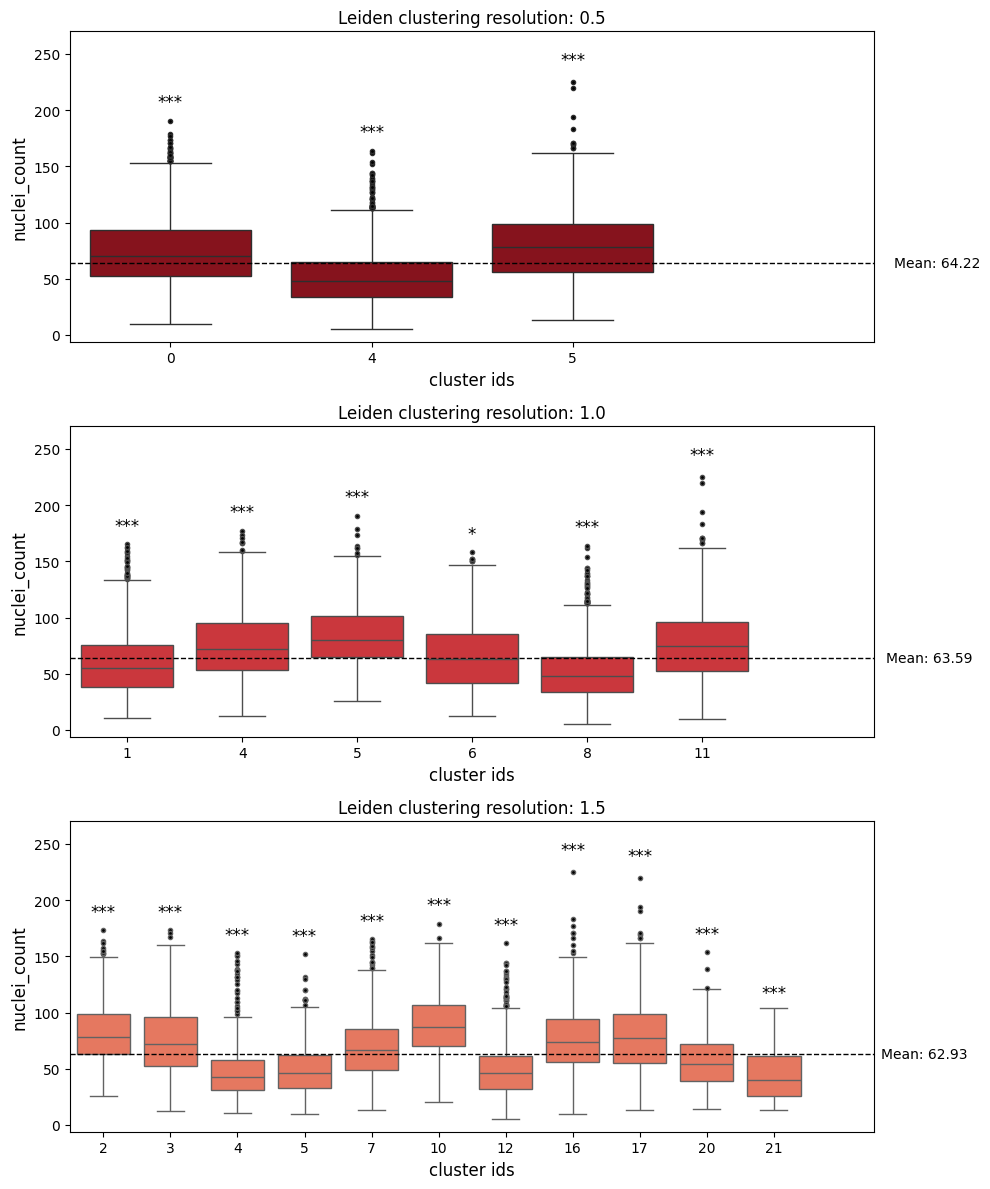

In [83]:
# Plot setup
nuclei_label = 'nuclei_count'
overall_mean = agg_df_leiden[nuclei_label].mean()

# Cluster config
cluster_levels = ['leiden_0.5', 'leiden_1.0', 'leiden_1.5']
cluster_orders = [cluster_order_05_epi, cluster_order_10_epi, cluster_order_15_epi]
colors = ['#99000D', '#E21F26', '#FB6A4A']


fig, axes = plt.subplots(3, 1, figsize=(10, 12))
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

for i, (level, order, color) in enumerate(zip(cluster_levels, cluster_orders, colors)):
    # 只对选定 clusters 计算 mean
    level_mean = agg_df_leiden[agg_df_leiden[level].isin(order)][nuclei_label].mean()
    
    sns.boxplot(
        x=level, y=nuclei_label,
        data=agg_df_leiden[agg_df_leiden[level].isin(order)],
        order=order,
        ax=axes[i], color=color,
        flierprops=flierprops
    )
    
    axes[i].set_ylabel(nuclei_label, fontsize=12)
    axes[i].set_xlabel("cluster ids", fontsize=12)
    axes[i].set_title(f"Leiden clustering resolution: {level.split('_')[1]}", fontsize=12)
    
    # Draw level-specific mean line
    axes[i].axhline(y=level_mean, color='black', linestyle='--', linewidth=1)
    axes[i].text(len(order) + 0.6, level_mean, f"Mean: {level_mean:.2f}",
                 ha='left', va='center', fontsize=10, color='black')
    axes[i].set_xlim(-0.5, len(order) + 0.5)

    for j, cluster in enumerate(order):
        cluster_vals = agg_df_leiden[agg_df_leiden[level] == cluster][nuclei_label]
        
        if len(cluster_vals) > 1:
            # 与你指定 cluster 的平均值做 t-test
            tstat, pval = ttest_1samp(cluster_vals, level_mean)
            
            stars = ''
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            
            if stars:
                y_max = cluster_vals.max()
                y_star = y_max + 0.05 * y_max

                current_ylim_top = axes[i].get_ylim()[1]
                if y_star > current_ylim_top:
                    axes[i].set_ylim(top=y_star + 0.15 * y_max)

                axes[i].text(j, y_star, stars,
                             ha='center', va='bottom',
                             fontsize=12, color='black')

plt.tight_layout()
save_pt = f"{save_prefix}/epithelium_3levels_{nuclei_label}_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

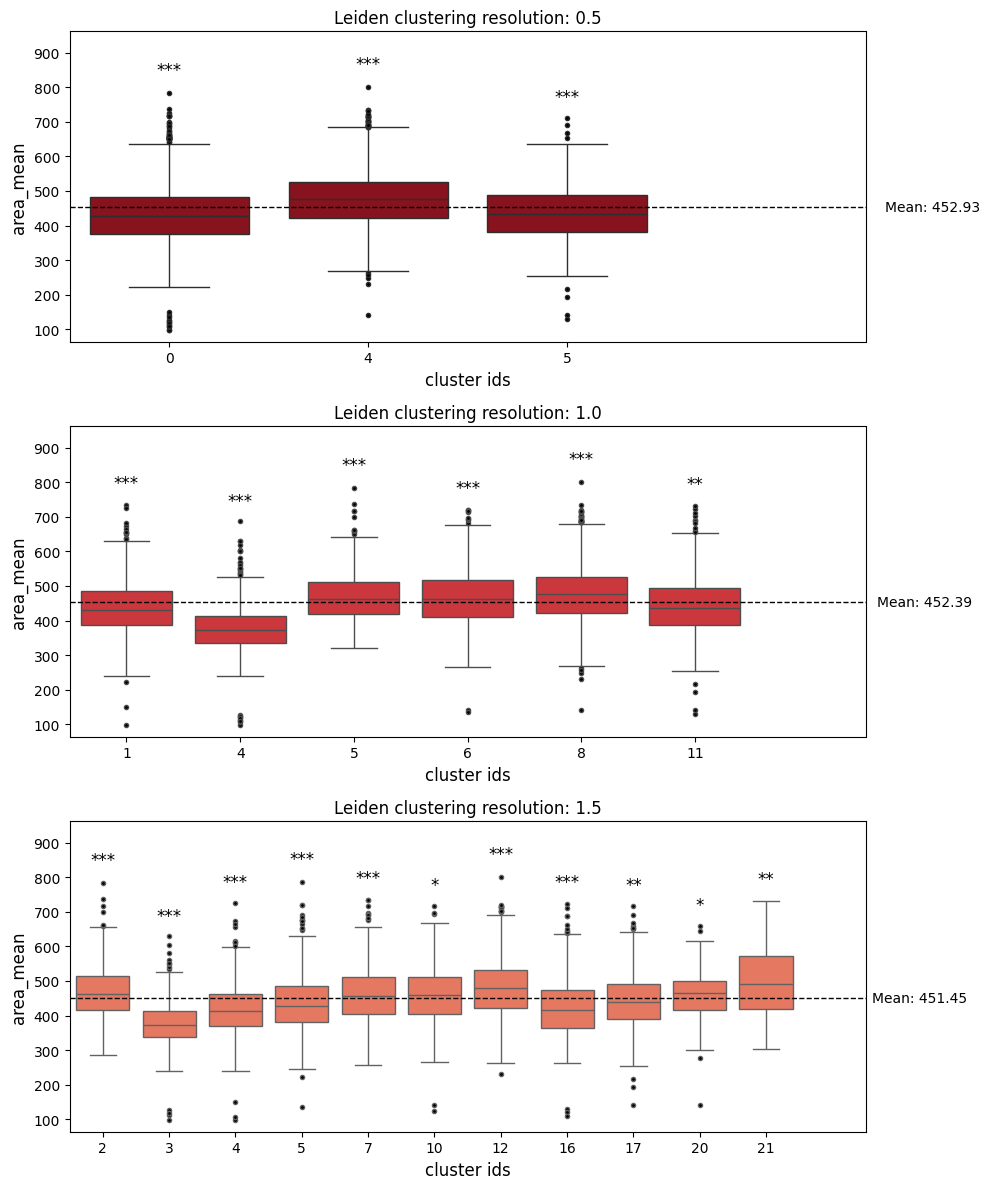

In [84]:
# Plot setup
nuclei_label = 'area_mean'
overall_mean = agg_df_leiden[nuclei_label].mean()

# Cluster config
cluster_levels = ['leiden_0.5', 'leiden_1.0', 'leiden_1.5']
cluster_orders = [cluster_order_05_epi, cluster_order_10_epi, cluster_order_15_epi]
colors = ['#99000D', '#E21F26', '#FB6A4A']


fig, axes = plt.subplots(3, 1, figsize=(10, 12))
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

for i, (level, order, color) in enumerate(zip(cluster_levels, cluster_orders, colors)):
    # 只对选定 clusters 计算 mean
    level_mean = agg_df_leiden[agg_df_leiden[level].isin(order)][nuclei_label].mean()
    
    sns.boxplot(
        x=level, y=nuclei_label,
        data=agg_df_leiden[agg_df_leiden[level].isin(order)],
        order=order,
        ax=axes[i], color=color,
        flierprops=flierprops
    )
    
    axes[i].set_ylabel(nuclei_label, fontsize=12)
    axes[i].set_xlabel("cluster ids", fontsize=12)
    axes[i].set_title(f"Leiden clustering resolution: {level.split('_')[1]}", fontsize=12)
    
    # Draw level-specific mean line
    axes[i].axhline(y=level_mean, color='black', linestyle='--', linewidth=1)
    axes[i].text(len(order) + 0.6, level_mean, f"Mean: {level_mean:.2f}",
                 ha='left', va='center', fontsize=10, color='black')
    axes[i].set_xlim(-0.5, len(order) + 0.5)

    for j, cluster in enumerate(order):
        cluster_vals = agg_df_leiden[agg_df_leiden[level] == cluster][nuclei_label]
        
        if len(cluster_vals) > 1:
            # 与你指定 cluster 的平均值做 t-test
            tstat, pval = ttest_1samp(cluster_vals, level_mean)
            
            stars = ''
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            
            if stars:
                y_max = cluster_vals.max()
                y_star = y_max + 0.05 * y_max

                current_ylim_top = axes[i].get_ylim()[1]
                if y_star > current_ylim_top:
                    axes[i].set_ylim(top=y_star + 0.15 * y_max)

                axes[i].text(j, y_star, stars,
                             ha='center', va='bottom',
                             fontsize=12, color='black')

plt.tight_layout()
save_pt = f"{save_prefix}/epithelium_3levels_{nuclei_label}_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

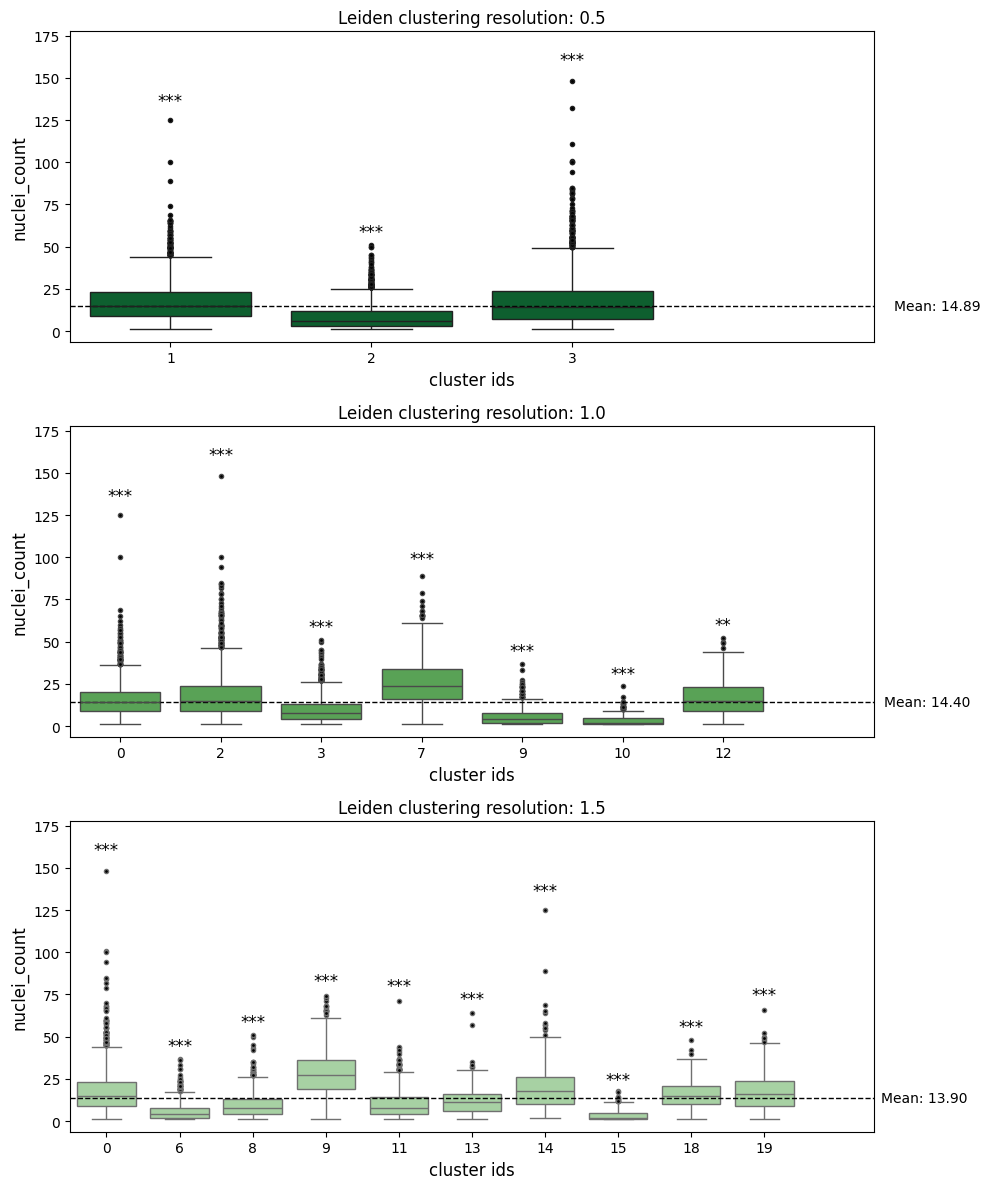

In [85]:
# Plot setup
nuclei_label = 'nuclei_count'
overall_mean = agg_df_leiden[nuclei_label].mean()

# Cluster config
cluster_levels = ['leiden_0.5', 'leiden_1.0', 'leiden_1.5']
cluster_orders = [cluster_order_05_str, cluster_order_10_str, cluster_order_15_str]
colors = ['#006D2C', '#4EAF49', '#A1D99B']


fig, axes = plt.subplots(3, 1, figsize=(10, 12))
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

for i, (level, order, color) in enumerate(zip(cluster_levels, cluster_orders, colors)):
    # 只对选定 clusters 计算 mean
    level_mean = agg_df_leiden[agg_df_leiden[level].isin(order)][nuclei_label].mean()
    
    sns.boxplot(
        x=level, y=nuclei_label,
        data=agg_df_leiden[agg_df_leiden[level].isin(order)],
        order=order,
        ax=axes[i], color=color,
        flierprops=flierprops
    )
    
    axes[i].set_ylabel(nuclei_label, fontsize=12)
    axes[i].set_xlabel("cluster ids", fontsize=12)
    axes[i].set_title(f"Leiden clustering resolution: {level.split('_')[1]}", fontsize=12)
    
    # Draw level-specific mean line
    axes[i].axhline(y=level_mean, color='black', linestyle='--', linewidth=1)
    axes[i].text(len(order) + 0.6, level_mean, f"Mean: {level_mean:.2f}",
                 ha='left', va='center', fontsize=10, color='black')
    axes[i].set_xlim(-0.5, len(order) + 0.5)

    for j, cluster in enumerate(order):
        cluster_vals = agg_df_leiden[agg_df_leiden[level] == cluster][nuclei_label]
        
        if len(cluster_vals) > 1:
            # 与你指定 cluster 的平均值做 t-test
            tstat, pval = ttest_1samp(cluster_vals, level_mean)
            
            stars = ''
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            
            if stars:
                y_max = cluster_vals.max()
                y_star = y_max + 0.05 * y_max

                current_ylim_top = axes[i].get_ylim()[1]
                if y_star > current_ylim_top:
                    axes[i].set_ylim(top=y_star + 0.15 * y_max)

                axes[i].text(j, y_star, stars,
                             ha='center', va='bottom',
                             fontsize=12, color='black')

plt.tight_layout()
save_pt = f"{save_prefix}/stroma_3levels_{nuclei_label}_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

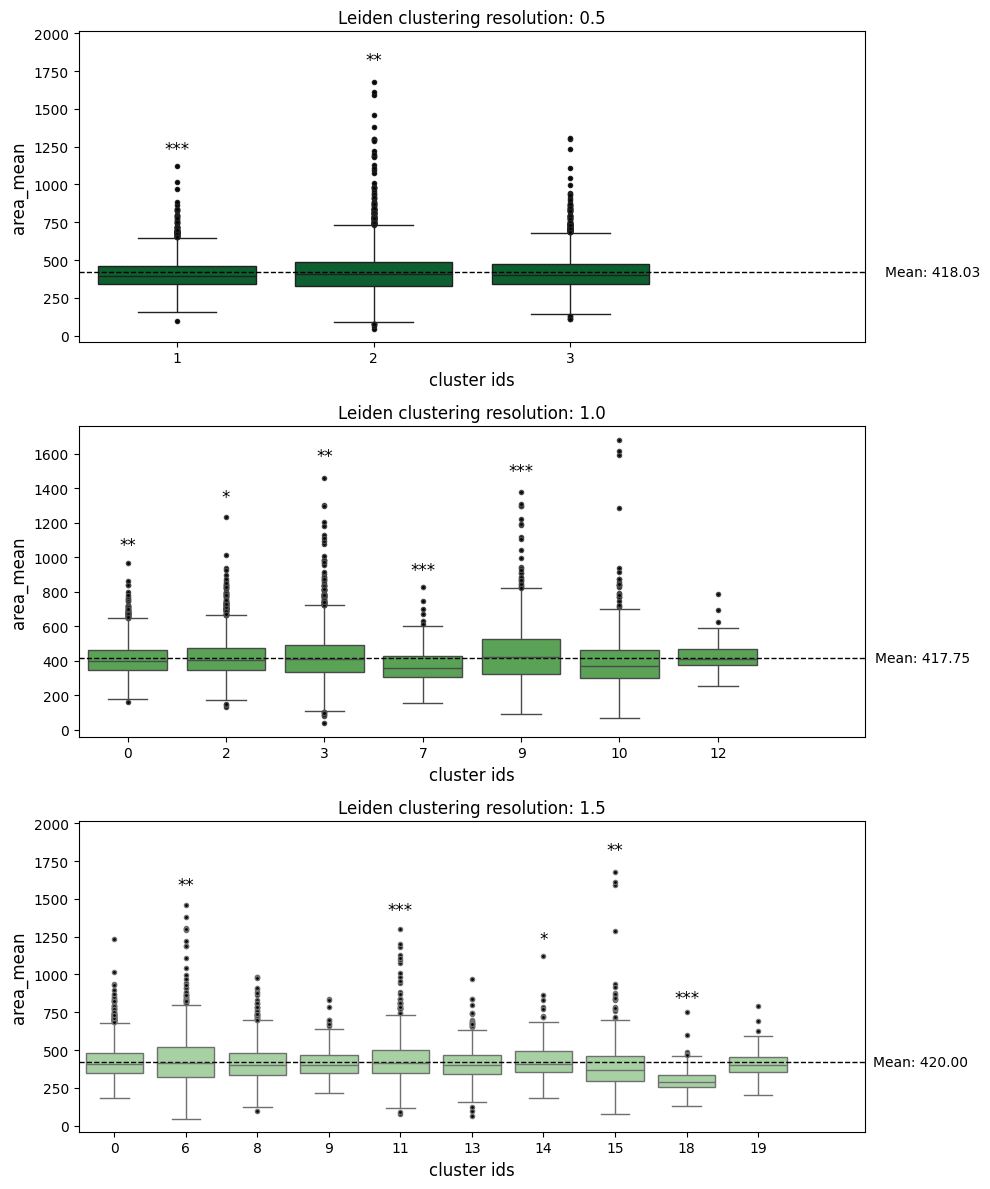

In [86]:
# Plot setup
nuclei_label = 'area_mean'
overall_mean = agg_df_leiden[nuclei_label].mean()

# Cluster config
cluster_levels = ['leiden_0.5', 'leiden_1.0', 'leiden_1.5']
cluster_orders = [cluster_order_05_str, cluster_order_10_str, cluster_order_15_str]
colors = ['#006D2C', '#4EAF49', '#A1D99B']


fig, axes = plt.subplots(3, 1, figsize=(10, 12))
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

for i, (level, order, color) in enumerate(zip(cluster_levels, cluster_orders, colors)):
    # 只对选定 clusters 计算 mean
    level_mean = agg_df_leiden[agg_df_leiden[level].isin(order)][nuclei_label].mean()
    
    sns.boxplot(
        x=level, y=nuclei_label,
        data=agg_df_leiden[agg_df_leiden[level].isin(order)],
        order=order,
        ax=axes[i], color=color,
        flierprops=flierprops
    )

    axes[i].set_ylabel(nuclei_label, fontsize=12)
    axes[i].set_xlabel("cluster ids", fontsize=12)
    axes[i].set_title(f"Leiden clustering resolution: {level.split('_')[1]}", fontsize=12)
    
    # Draw level-specific mean line
    axes[i].axhline(y=level_mean, color='black', linestyle='--', linewidth=1)
    axes[i].text(len(order) + 0.6, level_mean, f"Mean: {level_mean:.2f}",
                 ha='left', va='center', fontsize=10, color='black')
    axes[i].set_xlim(-0.5, len(order) + 0.5)

    for j, cluster in enumerate(order):
        cluster_vals = agg_df_leiden[agg_df_leiden[level] == cluster][nuclei_label]
        
        if len(cluster_vals) > 1:
            # 与你指定 cluster 的平均值做 t-test
            tstat, pval = ttest_1samp(cluster_vals, level_mean)
            
            stars = ''
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            
            if stars:
                y_max = cluster_vals.max()
                y_star = y_max + 0.05 * y_max

                current_ylim_top = axes[i].get_ylim()[1]
                if y_star > current_ylim_top:
                    axes[i].set_ylim(top=y_star + 0.15 * y_max)

                axes[i].text(j, y_star, stars,
                             ha='center', va='bottom',
                             fontsize=12, color='black')

plt.tight_layout()
save_pt = f"{save_prefix}/stroma_3levels_{nuclei_label}_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()